In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("Height_Weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

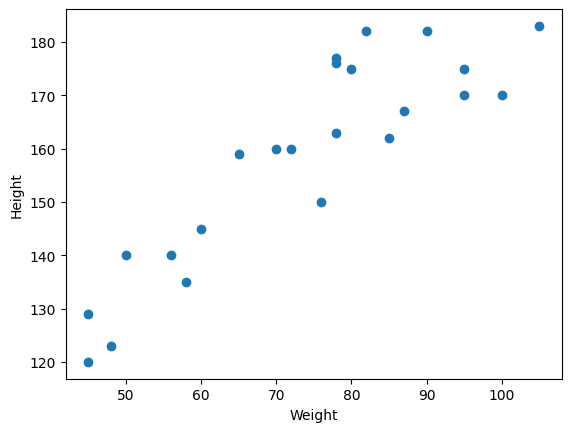

In [3]:
plt.scatter(df["Weight"],df["Height"])
plt.xlabel("Weight")
plt.ylabel("Height")

In [4]:
## divide our dataset into independent and dependent features
X=df[["Weight"]]  ##independent features
Y=df["Height"]  #3 dependent features

In [5]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [6]:
Y

0     120
1     135
2     123
3     145
4     160
5     163
6     175
7     182
8     170
9     176
10    182
11    175
12    183
13    170
14    162
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [7]:
## train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)


In [8]:
X.shape

(23, 1)

In [9]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

In [10]:
Y_train.shape,Y_test.shape

((18,), (5,))

In [11]:
## standarzie the dtaset train indepedent data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

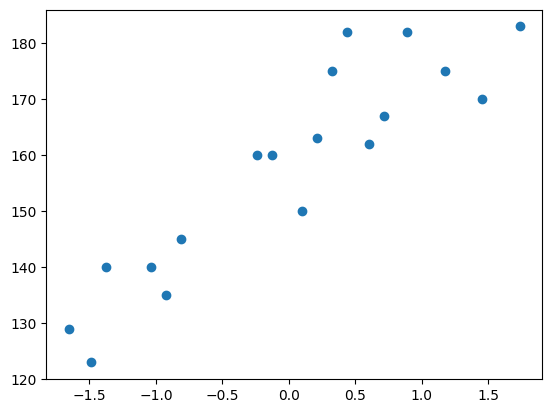

In [12]:
plt.scatter(X_train,Y_train)

In [13]:
## train the model
from sklearn.linear_model import LinearRegression

In [14]:
regression=LinearRegression()

In [15]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print("the slope or coefficient of weight is ", regression.coef_)

the slope or coefficient of weight is  [16.74963817]


In [17]:
print("the intercept of weight is ", regression.intercept_)

the intercept of weight is  157.83333333333334


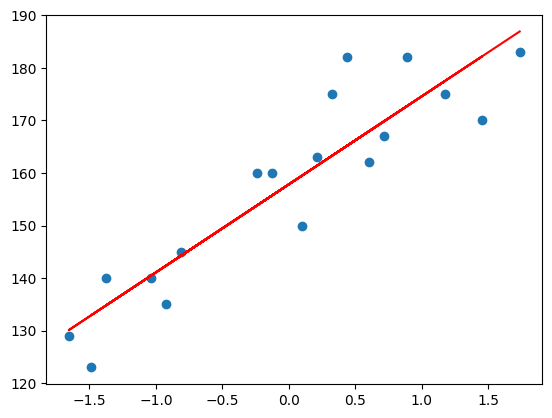

In [18]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train),'r')

In [19]:
##m prediction
Y_pred_test=regression.predict(X_test)

In [20]:
Y_pred_test,Y_test

(array([161.35807791, 161.35807791, 130.10884985, 177.4561651 ,
        149.04777595]),
 15    177
 9     176
 0     120
 8     170
 17    159
 Name: Height, dtype: int64)

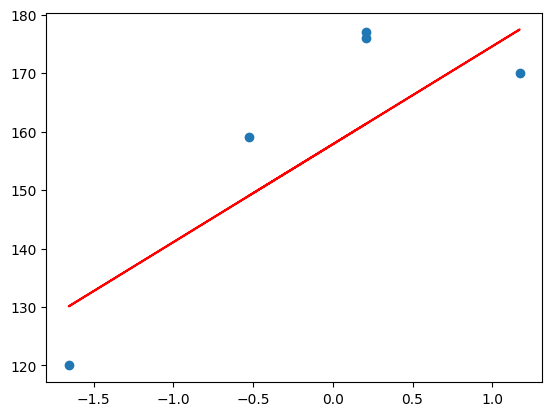

In [21]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,regression.predict(X_test),'r')

In [ ]:
## performance matrix
## MSE,MAE,RMSE
## r squared and adjusted r squared

In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(Y_test,Y_pred_test)
mae=mean_absolute_error(Y_test,Y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


143.17712314945783
11.560216634276747
11.96566434216913


In [23]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred_test)
print(score)

0.6811483984735038


In [25]:
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.5748645312980052

In [26]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
## new data point
scaled_weight=scaler.transform([[80]])
print(scaled_weight)

[[0.32350772]]


c:\Users\LAKSHYA CHOUDHARY\Desktop\DATA SCIENCE 1.2\python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
print("the height of new predicted value is ",regression.predict([scaled_weight[0]]))

the height of new predicted value is  [163.25197052]


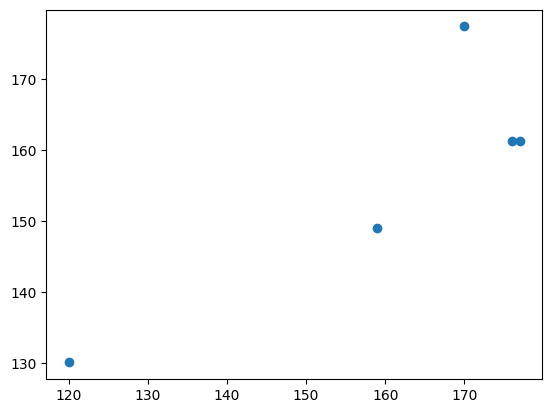

In [30]:
## assumption 
## plot a scatter plot for prediction
plt.scatter(Y_test,Y_pred_test)

In [31]:
## residuals
residulas=Y_test-Y_pred_test
residulas

15    15.641922
9     14.641922
0    -10.108850
8     -7.456165
17     9.952224
Name: Height, dtype: float64

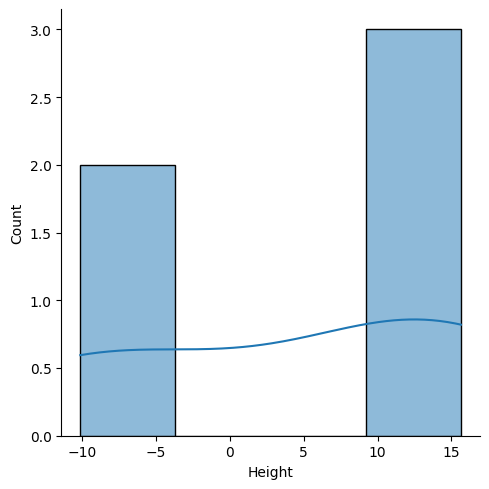

In [32]:
## plot this residuals
import seaborn as sns
sns.displot(residulas,kde='True')

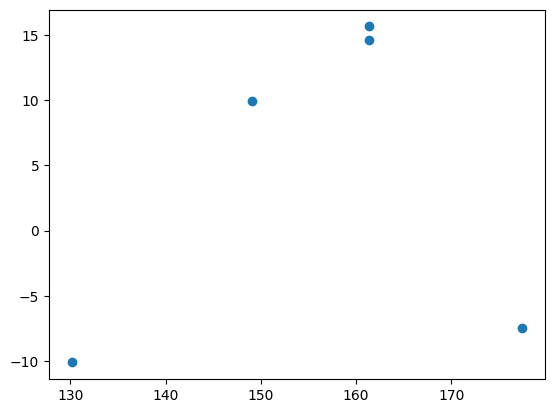

In [33]:
## scatter plot with respect to prediction and residuals
plt.scatter(Y_pred_test,residulas)

In [ ]:
## pickling the model